# Лабораторная работа №2  
## Обнаружение аномалий и выбросов в данных

**Датасет:** `blink.csv`  
**Производная очищенная версия:** `blink_cleaned.csv`  

В работе продолжается анализ датасета из лабораторной №1.  

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis, shapiro, zscore, probplot
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from IPython.display import display

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.3f}'.format)

## 1. Загрузка данных и подготовка рабочей версии

В `blink.csv` первая строка служебная, поэтому используем `skiprows=1`.  
Также, как и в лабораторной №1, считаем значения порядка `9.22e18` пропусками, а переполнение счётчика времени устраняем через разворачивание по модулю `2^40`.

In [6]:
# исходный файл
df_raw = pd.read_csv('blink.csv', skiprows=1)
# рабочая версия для лабораторной №2
df = pd.read_csv('blink_cleaned.csv')

##Введем новые числовые признаки для анализа:

In [7]:
#разность вдух временных меток
df['toa_gap'] = df['Timestamp ToA_unwrapped'] - df['timestampToA_unwrapped']

# разности между соседними измерениями внутри каждого anchorID
df = df.sort_values(['anchorID', 'sequenceID']).copy()
df['toa_diff'] = df.groupby('anchorID')['Timestamp ToA_unwrapped'].diff()

# логарифм разностей: нужен для проверки, станет ли распределение ближе к нормальному
df['log_toa_diff'] = np.log(df['toa_diff'])

# остатки после удаления линейного тренда
tmp = df.dropna(subset=['Timestamp ToA_unwrapped']).copy()
X = pd.get_dummies(tmp[['sequenceID', 'anchorID']], columns=['anchorID'], drop_first=True)
model = LinearRegression().fit(X, tmp['Timestamp ToA_unwrapped'])
tmp['toa_resid'] = tmp['Timestamp ToA_unwrapped'] - model.predict(X)
df.loc[tmp.index, 'toa_resid'] = tmp['toa_resid']

print('Размер исходного датасета:', df_raw.shape)
print('Размер рабочей версии:', df.shape)
display(df.head())

Размер исходного датасета: (608, 8)
Размер рабочей версии: (608, 19)


,id,anchorID,tagID,sequenceID,pan,processed_flag,timestampToA,Timestamp ToA,timestampToA_clean,timestampToA_missing_ind,Timestamp ToA_clean,Timestamp ToA_missing_ind,wrap_count,Timestamp ToA_unwrapped,timestampToA_unwrapped,toa_gap,toa_diff,log_toa_diff,toa_resid
0,1,ANCH0001,TAG00001,0,0,1,"728,480,000,000.000",728480463493,"728,480,000,000.000",0,"728,480,463,493.000",0,0,"728,480,463,493.000","728,480,000,000.000","463,493.000",NaN,NaN,"209,460,698,492.103"
4,5,ANCH0001,TAG00001,1,0,1,"759,054,000,000.000",759053775951,"759,054,000,000.000",0,"759,053,775,951.000",0,0,"759,053,775,951.000","759,054,000,000.000","-224,049.000","30,573,312,458.000",24.143,"204,463,792,507.162"
8,9,ANCH0001,TAG00001,2,0,1,"773,513,000,000.000",773512892482,"773,513,000,000.000",0,"773,512,892,482.000",0,0,"773,512,892,482.000","773,513,000,000.000","-107,518.000","14,459,116,531.000",23.395,"183,352,690,595.221"
10,11,ANCH0001,TAG00001,3,0,1,"794,137,000,000.000",794136559076,"794,137,000,000.000",0,"794,136,559,076.000",0,0,"794,136,559,076.000","794,137,000,000.000","-440,924.000","20,623,666,594.000",23.750,"168,406,138,746.279"
12,13,ANCH0001,TAG00001,4,0,1,"809,604,000,000.000",809603984772,"809,604,000,000.000",0,"809,603,984,772.000",0,0,"809,603,984,772.000","809,604,000,000.000","-15,228.000","15,467,425,696.000",23.462,"148,303,345,999.338"


## Задание 1. Загрузка и профилирование данных

In [8]:
print('Информация о датасете:')
print()
df.info()

Информация о датасете:

<class 'pandas.core.frame.DataFrame'>
Index: 608 entries, 0 to 606
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         608 non-null    int64  
 1   anchorID                   608 non-null    object 
 2   tagID                      608 non-null    object 
 3   sequenceID                 608 non-null    int64  
 4   pan                        608 non-null    int64  
 5   processed_flag             608 non-null    int64  
 6   timestampToA               608 non-null    float64
 7   Timestamp ToA              608 non-null    int64  
 8   timestampToA_clean         603 non-null    float64
 9   timestampToA_missing_ind   608 non-null    int64  
 10  Timestamp ToA_clean        603 non-null    float64
 11  Timestamp ToA_missing_ind  608 non-null    int64  
 12  wrap_count                 608 non-null    int64  
 13  Timestamp ToA_unwrapped    603 

In [9]:
print('Описательные статистики по числовым признакам:')
display(df.describe())

Описательные статистики по числовым признакам:


,id,sequenceID,pan,processed_flag,timestampToA,Timestamp ToA,timestampToA_clean,timestampToA_missing_ind,Timestamp ToA_clean,Timestamp ToA_missing_ind,wrap_count,Timestamp ToA_unwrapped,timestampToA_unwrapped,toa_gap,toa_diff,log_toa_diff,toa_resid
count,608.000,608.000,608.000,608.000,608.000,608.000,603.000,608.000,603.000,608.000,608.000,603.000,603.000,603.000,594.000,594.000,603.000
mean,304.500,81.627,0.000,0.933,"75,850,650,479,690,352.000","75,850,667,230,087,408.000","572,954,646,333.758",0.008,"572,954,592,525.745",0.008,2.587,"3,433,872,907,584.690","3,433,872,961,392.703","-53,808.013","34,800,098,250.665",24.108,-0.000
std,175.659,47.436,0.000,0.251,"833,656,473,710,141,952.000","833,656,657,811,758,592.000","294,742,162,567.716",0.090,"294,742,088,256.594",0.090,1.609,"1,694,687,466,043.689","1,694,687,557,461.395","803,573.621","21,181,533,523.400",0.590,"181,075,320,739.954"
min,1.000,0.000,0.000,0.000,"10,078,952,500.000","10,078,952,500.000","10,078,952,500.000",0.000,"10,078,952,500.000",0.000,0.000,"728,480,462,804.000","728,480,000,000.000","-4,569,294.000","4,708,196,583.000",22.273,"-279,988,388,966.021"
25%,152.750,40.000,0.000,1.000,"337,984,000,000.000","337,983,651,689.000","337,984,000,000.000",0.000,"337,983,651,544.500",0.000,1.000,"1,825,479,484,997.500","1,825,479,627,776.000","-233,211.000","24,852,799,433.000",23.936,"-157,025,501,811.149"
50%,304.500,82.000,0.000,1.000,"584,733,000,000.000","584,733,088,928.000","584,733,000,000.000",0.000,"584,733,088,765.000",0.000,2.000,"3,219,826,205,334.000","3,219,823,255,552.000","-13,691.000","31,038,325,784.000",24.158,"-5,560,420,137.313"
75%,456.250,123.000,0.000,1.000,"820,991,000,000.000","820,990,574,160.750","819,914,000,000.000",0.000,"819,914,077,563.500",0.000,4.000,"5,084,316,832,316.000","5,084,316,511,104.000","196,806.500","31,988,082,292.250",24.189,"119,501,171,265.036"
max,608.000,163.000,0.000,1.000,"9,223,370,000,000,000,000.000","9,223,372,036,854,769,664.000","1,099,420,000,000.000",1.000,"1,099,419,460,081.000",1.000,5.000,"6,033,022,365,776.000","6,033,022,138,880.000","4,955,446.000","184,901,964,228.000",25.943,"387,637,908,421.762"


In [10]:
print('Количество пропусков по столбцам:')
display(df.isna().sum().sort_values(ascending=False))

print()
print('Подозрительные экстремальные значения в исходном файле:')
print('Максимум timestampToA в raw:', df_raw['timestampToA'].max())
print('Максимум Timestamp ToA в raw:', df_raw['Timestamp ToA'].max())

print()
print('Количество пропусков после очистки:')
print('timestampToA_missing_ind =', int(df['timestampToA_missing_ind'].sum()))
print('Timestamp ToA_missing_ind =', int(df['Timestamp ToA_missing_ind'].sum()))

Количество пропусков по столбцам:


,0
toa_diff,14
log_toa_diff,14
Timestamp ToA_clean,5
Timestamp ToA_unwrapped,5
timestampToA_unwrapped,5
toa_resid,5
timestampToA_clean,5
toa_gap,5
tagID,0
id,0



Подозрительные экстремальные значения в исходном файле:
Максимум timestampToA в raw: 9.22337e+18
Максимум Timestamp ToA в raw: 9223372036854770000

Количество пропусков после очистки:
timestampToA_missing_ind = 5
Timestamp ToA_missing_ind = 5


### Краткий анализ профилирования

1. В исходном датасете присутствуют аномально большие значения порядка `9.22e18`.  
   Их разумно трактовать как служебные коды ошибки, а не как реальные временные метки.

2. После очистки у нас остаются пропуски только в производных столбцах, где это естественно:
   - в очищенных версиях временных меток из-за замены sentinel-значений на `NaN`;
   - в `toa_diff` и `log_toa_diff`, потому что для первой записи внутри каждой группы `anchorID` разность посчитать нельзя.

3. Для дальнейшего визуального анализа выберем два числовых признака:
   - `Timestamp ToA_unwrapped` — очищенная и развёрнутая временная метка;
   - `toa_gap` — разность между двумя версиями времени прихода сигнала.

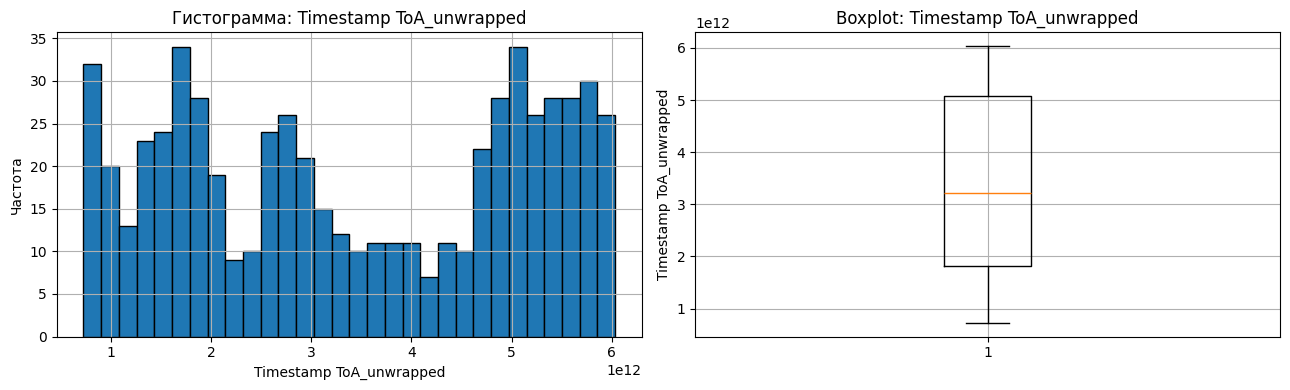

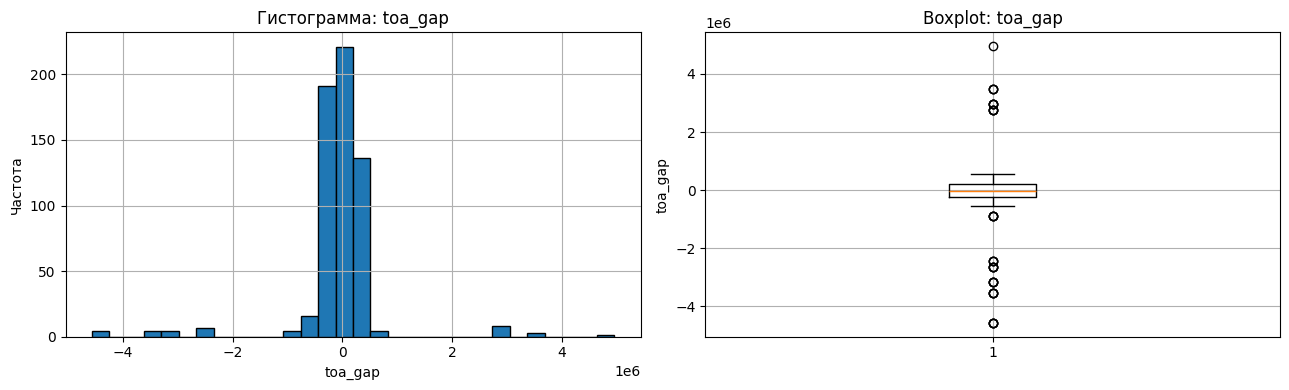

In [11]:
features_for_visual = ['Timestamp ToA_unwrapped', 'toa_gap']

for col in features_for_visual:
    x = df[col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(x, bins=30, edgecolor='black')
    axes[0].set_title(f'Гистограмма: {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Частота')

    axes[1].boxplot(x, vert=True)
    axes[1].set_title(f'Boxplot: {col}')
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

### Вывод по визуальному анализу

- Для `Timestamp ToA_unwrapped` распределение широкое и неоднородное: это объясняется тем, что временные метки растут по ходу последовательности. Явных одиночных экстремумов после очистки почти не видно.
- Для `toa_gap` основная масса значений сосредоточена около центра, но имеются заметные хвосты и точки за пределами "усов" boxplot. Это хороший кандидат на поиск выбросов.

## Задание 2. Проверка нормальности распределения

Проверим нормальность для трёх признаков:

1. `Timestamp ToA_unwrapped` — очищенная временная метка;
2. `toa_gap` — разность двух временных меток;
3. `log_toa_diff` — логарифм разности соседних временных меток внутри одного `anchorID`.

Выбор `log_toa_diff` важен потому, что исходные разности (`toa_diff`) сильно асимметричны, а логарифмирование обычно уменьшает правый хвост.

In [12]:
normality_features = ['Timestamp ToA_unwrapped', 'toa_gap', 'log_toa_diff']

rows = []
for col in normality_features:
    x = df[col].dropna()

    # для Шапиро-Уилка можно брать всю выборку, но здесь для стабильности оставим до 500 наблюдений
    if len(x) > 500:
        x_for_shapiro = x.sample(500, random_state=42)
    else:
        x_for_shapiro = x

    stat, p_value = shapiro(x_for_shapiro)

    rows.append({
        'feature': col,
        'count': len(x),
        'mean': x.mean(),
        'median': x.median(),
        'std': x.std(),
        'skew': skew(x),
        'kurtosis': kurtosis(x),
        'shapiro_W': stat,
        'shapiro_p': p_value
    })

stats_df = pd.DataFrame(rows)
display(stats_df)

,feature,count,mean,median,std,skew,kurtosis,shapiro_W,shapiro_p
0,Timestamp ToA_unwrapped,603,"3,433,872,907,584.690","3,219,826,205,334.000","1,694,687,466,043.689",-0.010,-1.462,0.918,0.000
1,toa_gap,603,"-53,808.013","-13,691.000","803,573.621",-0.973,15.247,0.605,0.000
2,log_toa_diff,594,24.108,24.158,0.590,-0.371,0.693,0.929,0.000


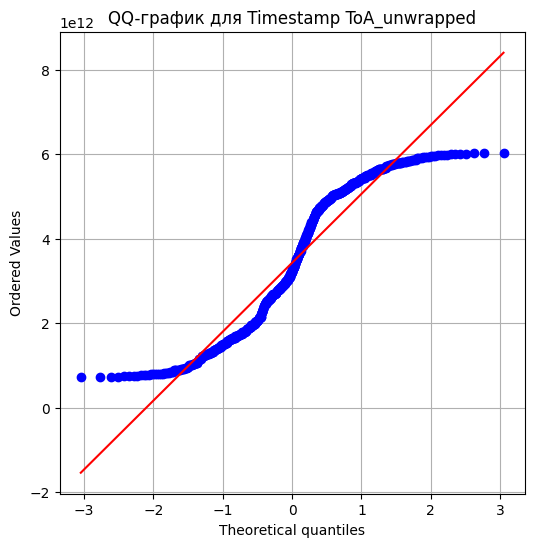

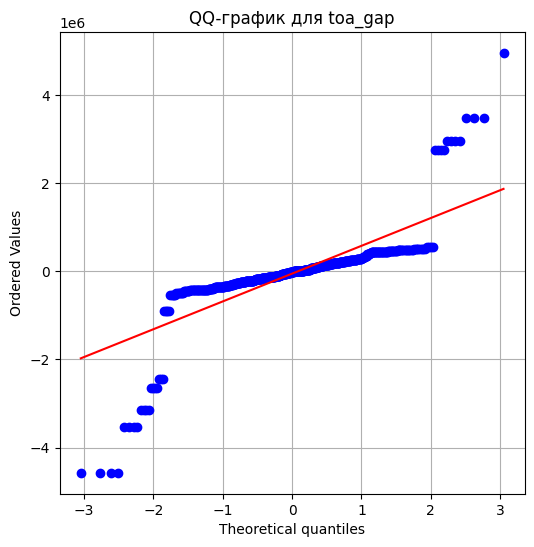

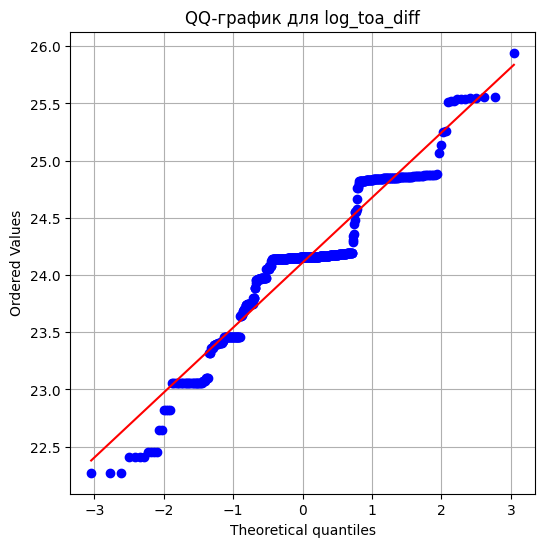

In [13]:
for col in normality_features:
    x = df[col].dropna()

    plt.figure(figsize=(6, 6))
    probplot(x, dist='norm', plot=plt)
    plt.title(f'QQ-график для {col}')
    plt.show()

### Формулировка гипотез

- **H0:** выборка подчиняется нормальному распределению  
- **H1:** выборка не подчиняется нормальному распределению  
- Уровень значимости: **α = 0.05**

In [14]:
alpha = 0.05

result_rows = []
for col in normality_features:
    x = df[col].dropna()
    if len(x) > 500:
        x_for_shapiro = x.sample(500, random_state=42)
    else:
        x_for_shapiro = x

    stat, p_value = shapiro(x_for_shapiro)
    decision = 'Отклоняем H0' if p_value < alpha else 'Нет оснований отклонить H0'

    result_rows.append({
        'feature': col,
        'p_value': p_value,
        'decision': decision
    })

normality_result = pd.DataFrame(result_rows)
display(normality_result)

,feature,p_value,decision
0,Timestamp ToA_unwrapped,0.000,Отклоняем H0
1,toa_gap,0.000,Отклоняем H0
2,log_toa_diff,0.000,Отклоняем H0


### Вывод по нормальности

Для всех трёх признаков гипотеза о нормальности **отклоняется** (`p-value < 0.05`).  
Однако среди рассмотренных признаков **`log_toa_diff` ближе всего к нормальному распределению**:

- асимметрия по модулю меньше, чем у `toa_gap`;
- эксцесс ближе к нулю;
- QQ-график выглядит заметно лучше, чем у `toa_gap`.

Поэтому именно `log_toa_diff` будем использовать в статистических методах обнаружения выбросов как признак, который **наиболее близок к нормальному**, хотя идеально нормальным всё равно не является.

## Задание 3. Обнаружение выбросов статистическими методами

Выбранный признак: **`log_toa_diff`**

In [15]:
x = df['log_toa_diff'].dropna().copy()

# Z-score
z_values = pd.Series(np.abs(zscore(x)), index=x.index)
z_outliers = z_values[z_values > 3]

# IQR
Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = x[(x < lower_bound) | (x > upper_bound)]

print('Z-score: количество выбросов =', len(z_outliers))
print('IQR: количество выбросов =', len(iqr_outliers))
print()
print('Q1 =', Q1)
print('Q3 =', Q3)
print('IQR =', IQR)
print('Нижняя граница =', lower_bound)
print('Верхняя граница =', upper_bound)

print()
print('Первые выбросы по Z-score:')
display(df.loc[z_outliers.index, ['id', 'anchorID', 'sequenceID', 'toa_diff', 'log_toa_diff']])

print('Первые 15 выбросов по IQR:')
display(df.loc[iqr_outliers.index[:15], ['id', 'anchorID', 'sequenceID', 'toa_diff', 'log_toa_diff']])

Z-score: количество выбросов = 4
IQR: количество выбросов = 239

Q1 = 23.936191321745213
Q3 = 24.18862924201028
IQR = 0.2524379202650664
Нижняя граница = 23.557534441347613
Верхняя граница = 24.56728612240788

Первые выбросы по Z-score:


,id,anchorID,sequenceID,toa_diff,log_toa_diff
321,322,ANCH0001,87,"184,901,964,228.000",25.943
139,140,ANCH0002,38,"4,708,196,603.000",22.273
144,145,ANCH0003,38,"4,708,196,583.000",22.273
141,142,ANCH0004,38,"4,708,196,606.000",22.273


Первые 15 выбросов по IQR:


,id,anchorID,sequenceID,toa_diff,log_toa_diff
8,9,ANCH0001,2,"14,459,116,531.000",23.395
12,13,ANCH0001,4,"15,467,425,696.000",23.462
16,17,ANCH0001,5,"10,310,093,387.000",23.056
32,33,ANCH0001,9,"92,810,410,121.000",25.254
41,42,ANCH0001,12,"93,208,266,627.000",25.258
48,49,ANCH0001,14,"61,507,799,363.000",24.842
56,57,ANCH0001,16,"60,199,208,635.000",24.821
60,61,ANCH0001,17,"63,260,110,635.000",24.871
63,64,ANCH0001,18,"14,689,988,282.000",23.410
91,92,ANCH0001,25,"62,151,338,312.000",24.853


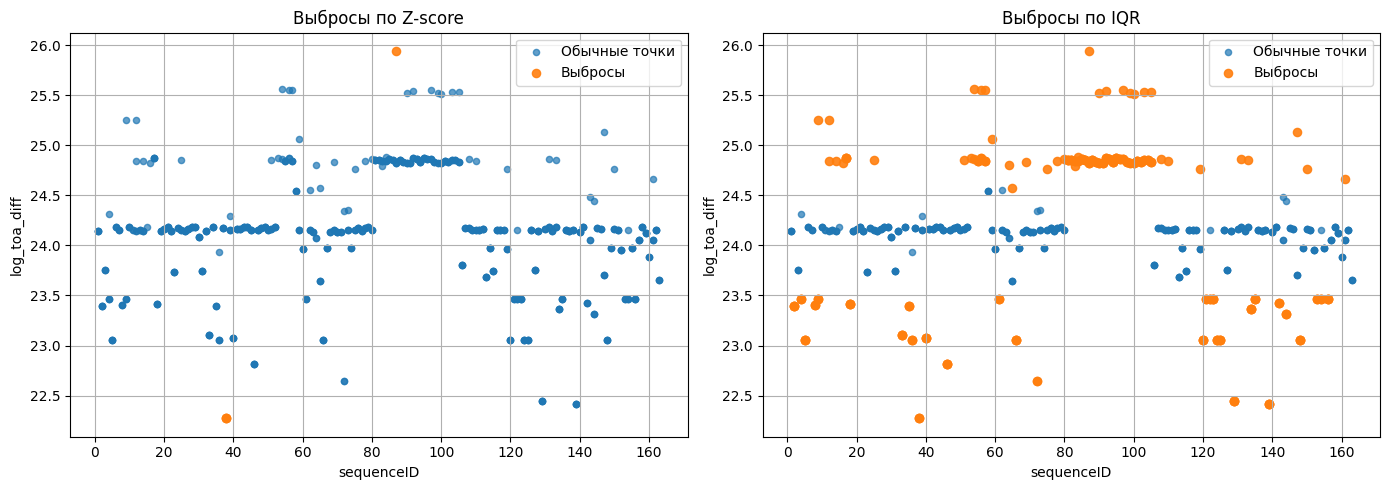

In [16]:
plot_df = df.dropna(subset=['log_toa_diff']).copy()
plot_df['is_z_outlier'] = plot_df.index.isin(z_outliers.index)
plot_df['is_iqr_outlier'] = plot_df.index.isin(iqr_outliers.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Z-score
axes[0].scatter(
    plot_df.loc[~plot_df['is_z_outlier'], 'sequenceID'],
    plot_df.loc[~plot_df['is_z_outlier'], 'log_toa_diff'],
    s=20,
    alpha=0.7,
    label='Обычные точки'
)
axes[0].scatter(
    plot_df.loc[plot_df['is_z_outlier'], 'sequenceID'],
    plot_df.loc[plot_df['is_z_outlier'], 'log_toa_diff'],
    s=35,
    alpha=0.9,
    label='Выбросы'
)
axes[0].set_title('Выбросы по Z-score')
axes[0].set_xlabel('sequenceID')
axes[0].set_ylabel('log_toa_diff')
axes[0].legend()

# IQR
axes[1].scatter(
    plot_df.loc[~plot_df['is_iqr_outlier'], 'sequenceID'],
    plot_df.loc[~plot_df['is_iqr_outlier'], 'log_toa_diff'],
    s=20,
    alpha=0.7,
    label='Обычные точки'
)
axes[1].scatter(
    plot_df.loc[plot_df['is_iqr_outlier'], 'sequenceID'],
    plot_df.loc[plot_df['is_iqr_outlier'], 'log_toa_diff'],
    s=35,
    alpha=0.9,
    label='Выбросы'
)
axes[1].set_title('Выбросы по IQR')
axes[1].set_xlabel('sequenceID')
axes[1].set_ylabel('log_toa_diff')
axes[1].legend()

plt.tight_layout()
plt.show()

### Сравнительный анализ Z-score и IQR

- **Z-score** выделяет только самые крайние точки, где отклонение действительно очень велико.
- **IQR** оказался гораздо чувствительнее и выделил заметно больше наблюдений.
- Все выбросы, найденные методом Z-score, также попали в выбросы по IQR.

Для этого датасета IQR работает как более строгий фильтр, а Z-score — как метод для выделения только самых экстремальных случаев.  
С практической точки зрения здесь полезно смотреть на пересечение результатов: точки, найденные обоими методами, действительно наиболее интересны для предметного анализа.

## Задание 4. Метод локальной плотности

Для метода локальной плотности возьмём два числовых признака:

- `log_toa_diff`
- `toa_gap`

Почему именно они:
- `log_toa_diff` описывает скорость изменения временных меток;
- `toa_gap` показывает рассогласование между двумя версиями времени прихода сигнала.


In [17]:
local_df = df.dropna(subset=['log_toa_diff', 'toa_gap']).copy()

features = ['log_toa_diff', 'toa_gap']
X = local_df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Размер выборки для метода локальной плотности:', X.shape)
display(local_df[features].head())

Размер выборки для метода локальной плотности: (594, 2)


,log_toa_diff,toa_gap
4,24.143,"-224,049.000"
8,23.395,"-107,518.000"
10,23.750,"-440,924.000"
12,23.462,"-15,228.000"
16,23.056,"78,159.000"


In [18]:
k_values = [5, 7, 9, 10]
metrics = ['euclidean', 'manhattan']

summary_rows = []
all_results = {}

for metric in metrics:
    for k in k_values:
        nn = NearestNeighbors(n_neighbors=k + 1, metric=metric)
        nn.fit(X_scaled)

        distances, indices = nn.kneighbors(X_scaled)

        # первый сосед - сама точка, поэтому его не учитываем
        kth_distance = distances[:, -1]
        mean_distance = distances[:, 1:].mean(axis=1)
        density = 1 / mean_distance

        threshold = np.quantile(mean_distance, 0.95)
        anomaly_flag = mean_distance >= threshold

        result_df = local_df.copy()
        result_df['kth_distance'] = kth_distance
        result_df['mean_distance'] = mean_distance
        result_df['local_density'] = density
        result_df['is_anomaly'] = anomaly_flag

        all_results[(metric, k)] = result_df

        summary_rows.append({
            'metric': metric,
            'k': k,
            'threshold_95': threshold,
            'anomaly_count': int(anomaly_flag.sum()),
            'max_mean_distance': mean_distance.max(),
            'min_density': density.min()
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,metric,k,threshold_95,anomaly_count,max_mean_distance,min_density
0,euclidean,5,0.314,30,2.088,0.479
1,euclidean,7,0.387,30,2.201,0.454
2,euclidean,9,0.481,30,2.330,0.429
3,euclidean,10,0.542,30,2.391,0.418
4,manhattan,5,0.342,30,2.168,0.461
5,manhattan,7,0.455,30,2.284,0.438
6,manhattan,9,0.529,30,2.477,0.404
7,manhattan,10,0.612,30,2.614,0.383


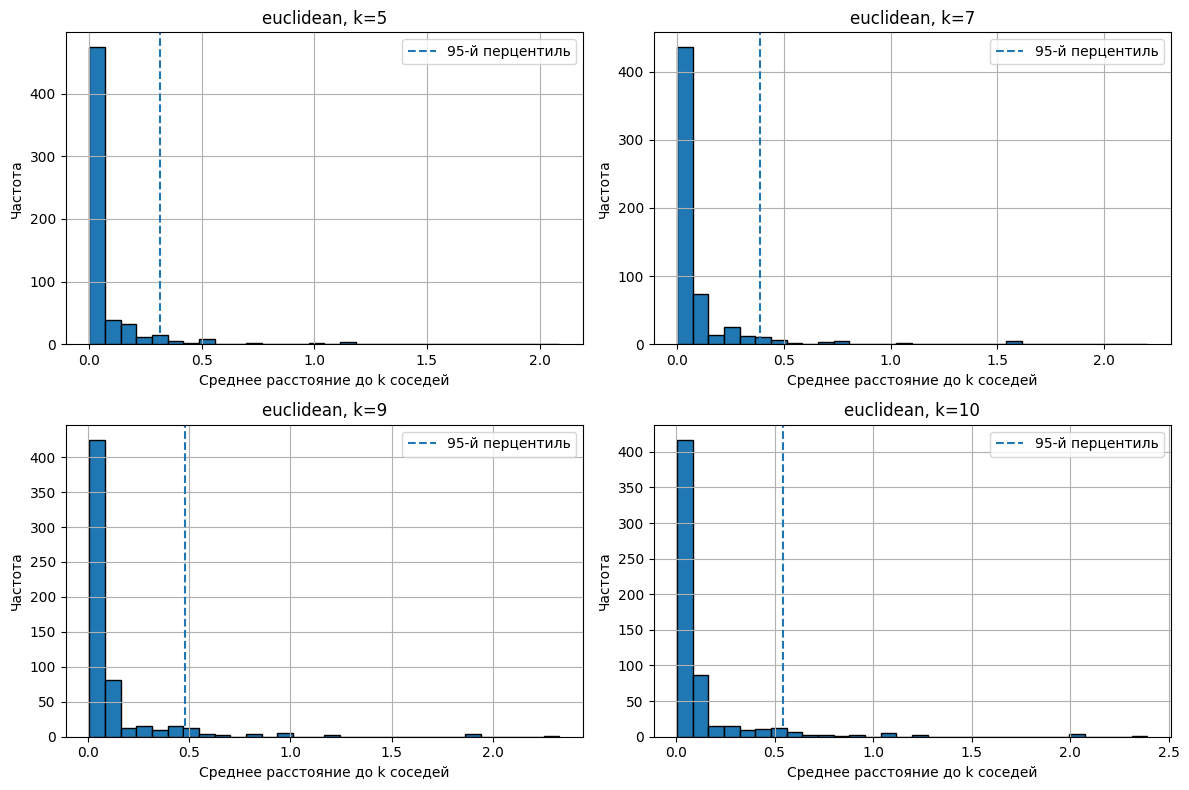

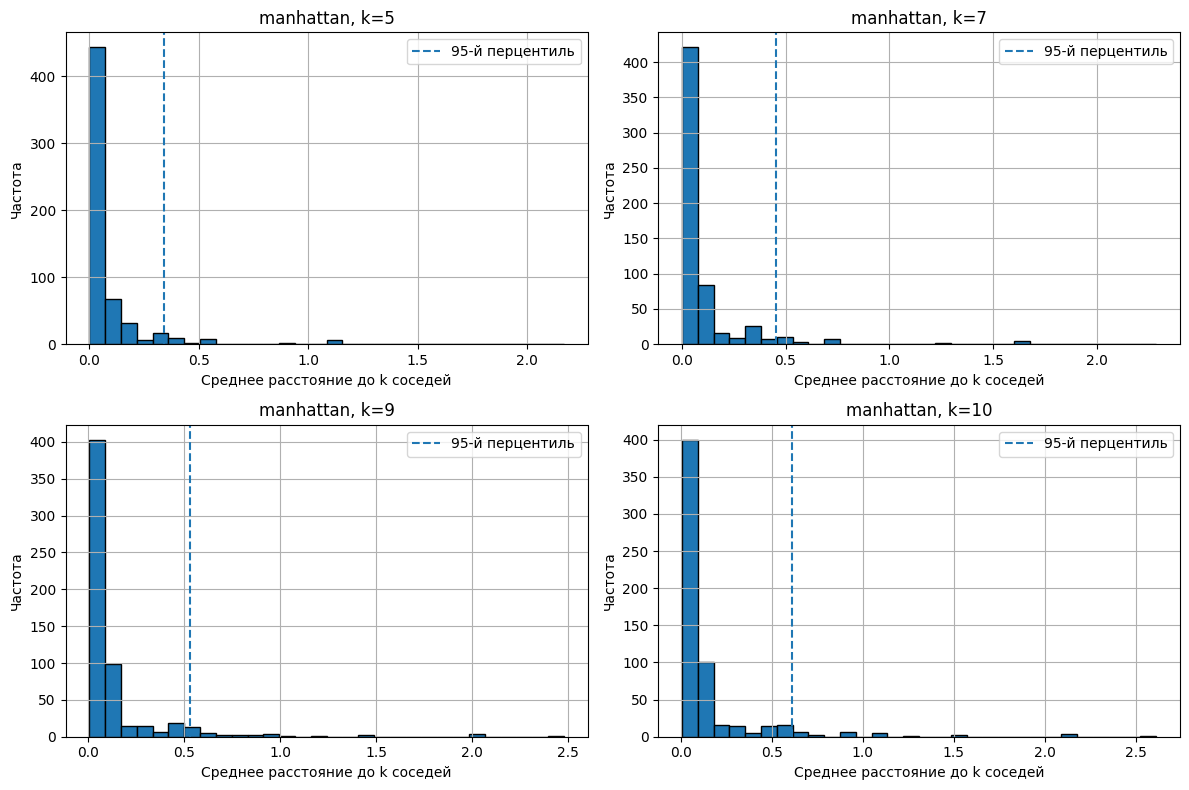

In [19]:
for metric in metrics:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for i, k in enumerate(k_values):
        result_df = all_results[(metric, k)]
        axes[i].hist(result_df['mean_distance'], bins=30, edgecolor='black')
        axes[i].axvline(result_df['mean_distance'].quantile(0.95), linestyle='--', label='95-й перцентиль')
        axes[i].set_title(f'{metric}, k={k}')
        axes[i].set_xlabel('Среднее расстояние до k соседей')
        axes[i].set_ylabel('Частота')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

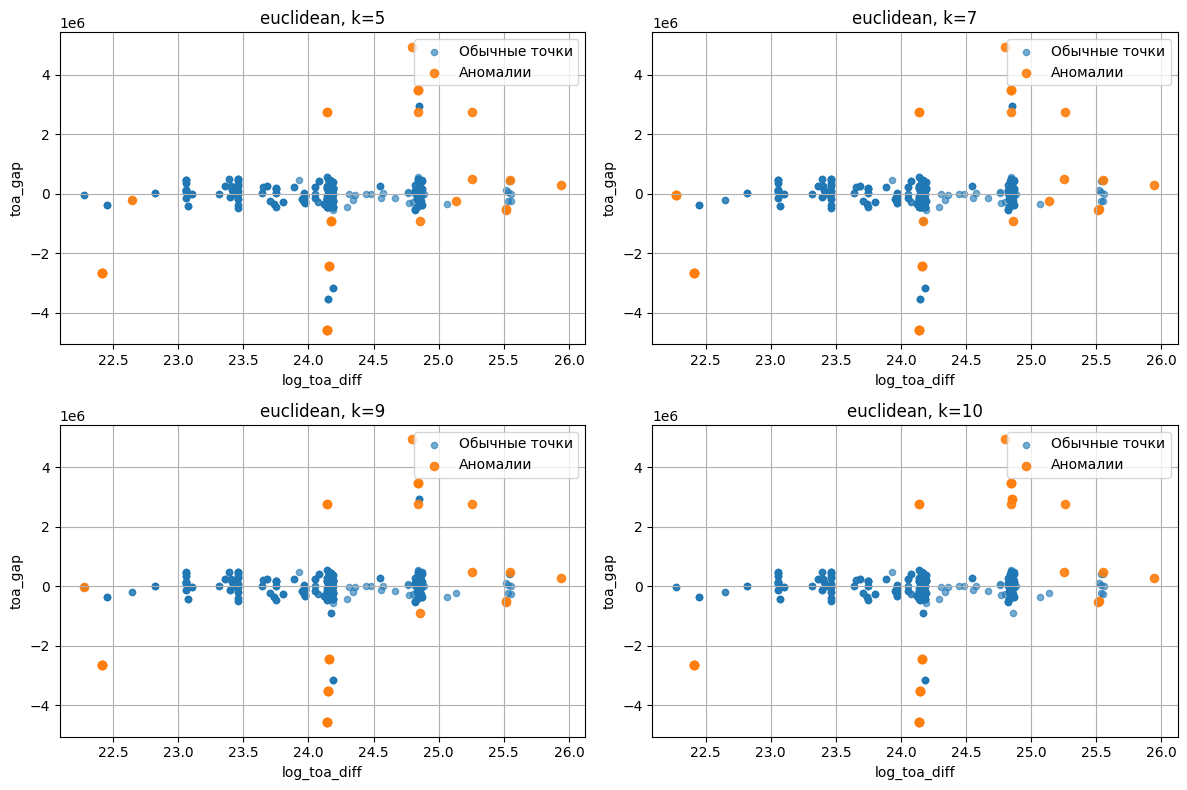

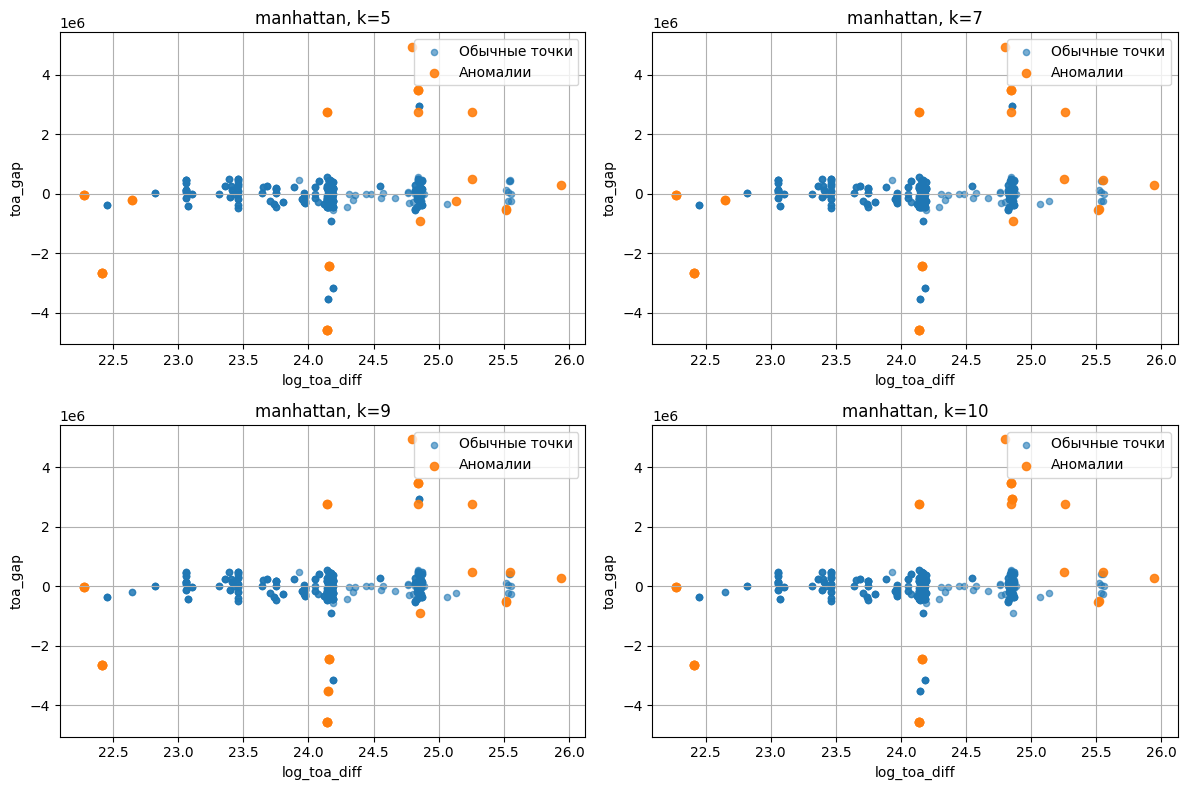

In [20]:
for metric in metrics:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for i, k in enumerate(k_values):
        result_df = all_results[(metric, k)]

        normal_points = result_df[~result_df['is_anomaly']]
        anomaly_points = result_df[result_df['is_anomaly']]

        axes[i].scatter(
            normal_points['log_toa_diff'],
            normal_points['toa_gap'],
            s=20,
            alpha=0.6,
            label='Обычные точки'
        )
        axes[i].scatter(
            anomaly_points['log_toa_diff'],
            anomaly_points['toa_gap'],
            s=35,
            alpha=0.9,
            label='Аномалии'
        )

        axes[i].set_title(f'{metric}, k={k}')
        axes[i].set_xlabel('log_toa_diff')
        axes[i].set_ylabel('toa_gap')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

In [21]:
# анализ устойчивости метода при изменении k
stability_rows = []

for metric in metrics:
    sets = {}
    for k in k_values:
        anomaly_idx = set(all_results[(metric, k)].index[all_results[(metric, k)]['is_anomaly']])
        sets[k] = anomaly_idx

    common_idx = set.intersection(*[sets[k] for k in k_values])
    union_idx = set.union(*[sets[k] for k in k_values])

    stability_rows.append({
        'metric': metric,
        'stable_anomalies_in_all_k': len(common_idx),
        'anomalies_in_union': len(union_idx),
        'stability_ratio': len(common_idx) / len(union_idx)
    })

    # попарные пересечения
    pairs = [(5, 7), (7, 9), (9, 10), (5, 10)]
    for k1, k2 in pairs:
        inter = len(sets[k1] & sets[k2])
        union = len(sets[k1] | sets[k2])
        stability_rows.append({
            'metric': metric,
            'pair': f'{k1}-{k2}',
            'intersection': inter,
            'jaccard': inter / union
        })

stability_df = pd.DataFrame(stability_rows)
display(stability_df)

,metric,stable_anomalies_in_all_k,anomalies_in_union,stability_ratio,pair,intersection,jaccard
0,euclidean,24.000,39.000,0.615,NaN,NaN,NaN
1,euclidean,NaN,NaN,NaN,5-7,27.000,0.818
2,euclidean,NaN,NaN,NaN,7-9,26.000,0.765
3,euclidean,NaN,NaN,NaN,9-10,28.000,0.875
4,euclidean,NaN,NaN,NaN,5-10,24.000,0.667
5,manhattan,26.000,36.000,0.722,NaN,NaN,NaN
6,manhattan,NaN,NaN,NaN,5-7,29.000,0.935
7,manhattan,NaN,NaN,NaN,7-9,28.000,0.875
8,manhattan,NaN,NaN,NaN,9-10,27.000,0.818
9,manhattan,NaN,NaN,NaN,5-10,26.000,0.765


In [22]:
print('Пример наиболее аномальных точек (Евклидово расстояние, k=7):')
top_anomalies = all_results[('euclidean', 7)].sort_values('mean_distance', ascending=False)
display(top_anomalies[['id', 'anchorID', 'sequenceID', 'toa_diff', 'log_toa_diff', 'toa_gap', 'mean_distance']].head(15))

Пример наиболее аномальных точек (Евклидово расстояние, k=7):


,id,anchorID,sequenceID,toa_diff,log_toa_diff,toa_gap,mean_distance
310,311,ANCH0004,83,"58,782,005,990.000",24.797,"4,955,446.000",2.201
515,516,ANCH0003,139,"5,417,441,913.000",22.413,"-2,641,991.000",1.609
517,518,ANCH0002,139,"5,417,441,908.000",22.413,"-2,641,962.000",1.609
519,520,ANCH0004,139,"5,417,441,919.000",22.413,"-2,641,829.000",1.609
513,514,ANCH0001,139,"5,417,441,912.000",22.413,"-2,641,625.000",1.609
42,43,ANCH0002,12,"30,455,272,469.000",24.140,"2,754,260.000",1.087
44,45,ANCH0004,12,"30,455,272,473.000",24.140,"2,754,668.000",1.087
41,42,ANCH0001,12,"93,208,266,627.000",25.258,"2,754,907.000",0.846
321,322,ANCH0001,87,"184,901,964,228.000",25.943,"299,227.000",0.757
523,524,ANCH0003,140,"30,438,072,697.000",24.139,"-4,569,294.000",0.736


### Вывод по методу локальной плотности

1. При использовании верхних **5%** значений среднего расстояния до соседей метод стабильно выделяет около 30 аномалий, что соответствует условию задания.

2. Аномальные точки концентрируются там, где:
   - либо `toa_gap` слишком велик по модулю;
   - либо `log_toa_diff` слишком мал или слишком велик по сравнению с основной массой точек.

3. Изменение `k` влияет на состав аномалий, но наиболее "сильные" аномалии сохраняются почти при всех значениях `k`.
   Это говорит о достаточной устойчивости метода.

4. Манхэттенское расстояние дало немного более стабильный набор аномалий, чем Евклидово, но в целом оба подхода выделяют очень похожие подозрительные наблюдения.